# Avian magnetoreception on a real quantum computer

**GPT as a co-scientist for a quantum-biology experiment.**

Migratory birds cross oceans and continents and arrive within meters of where they
started a year earlier. The leading explanation for how they read Earth's magnetic
field is not an organ or a mineral. It is a quantum effect inside a protein in the
eye: the *radical-pair mechanism*.

In this notebook GPT acts as a research partner. GPT designs the quantum
circuit, we run it on a simulator and on IBM's real superconducting hardware, GPT
interprets what came back, and then GPT answers the question most demos avoid:
does this problem actually need a quantum computer at all?

## The radical-pair mechanism

Light hits a cryptochrome protein in the bird's retina and knocks an electron from one
molecule to another. That leaves two unpaired electron spins, one on each molecule: a
*radical pair*. The pair is born in a quantum **singlet** state, where the two spins
are perfectly anti-correlated.

Left alone, the pair does not stay a singlet. The two spins coherently oscillate
between the singlet state and the three **triplet** states. Two things drive that
oscillation:

- the **Zeeman interaction** with Earth's magnetic field, and
- the **hyperfine interaction** with nearby atomic nuclei inside the molecule.

The chemistry that follows depends on whether the pair is a singlet or a triplet at the
moment it reacts, so the singlet-versus-triplet balance sets the amount of product the
reaction makes. Because the hyperfine coupling is **anisotropic** (it depends on
molecular orientation), that balance depends on the direction of the external field.
The protein becomes a chemical compass. The anisotropy is the whole trick. Remove it and
the direction sensitivity disappears.

> **In plain English.** Picture the two electrons as a pair of tiny spinning tops that
> start out perfectly in step. As they spin they drift in and out of step, and how fast
> they drift depends on which way the bird is facing in Earth's field. The bird's body
> turns that timing difference into a sense of direction. That is the whole compass.

## What this notebook does

We model the smallest honest version of this system: three spin-1/2 particles. Qubits 0
and 1 are the two electrons, prepared in a singlet. Qubit 2 is one hyperfine-coupled
nucleus. The energy rulebook (the Hamiltonian) is

$$
H \;=\; \underbrace{X_0X_2 + Y_0Y_2 + 3\,Z_0Z_2}_{\textstyle \text{hyperfine: electron 0 feels the nucleus}}
\;+\; \underbrace{B_x\,(X_0{+}X_1) + B_z\,(Z_0{+}Z_1)}_{\textstyle \text{Zeeman: both electrons feel Earth's field}}
$$

| symbol | what it is |
| :-- | :-- |
| `q0`, `q1` | the two electron spins, prepared as a singlet |
| `q2` | one nearby atomic nucleus |
| `Bx`, `Bz` | the sideways and vertical parts of the magnetic field |
| the 3 on `Z0Z2` | makes the coupling *anisotropic*, which is what creates direction sensing |

The observable is the **singlet survival probability** after a fixed time, swept over the
magnetic-field direction.

> **In plain English.** The formula above is just a rulebook for how the three spins push
> and pull on each other. The first group is one electron feeling its neighboring nucleus.
> The second is both electrons feeling Earth's field. Turn the field a different way and you
> change the push-and-pull, which changes the number we measure at the end.

The plan:

1. **GPT designs the circuit** from the Hamiltonian and the observable.
2. We **build and run** it on a simulator, and check it against exact theory and against a
   real IBM hardware run of the same circuit.
3. We take one **step up** to a more realistic flavin model on hardware.
4. **GPT interprets** the data.
5. **GPT assesses** whether quantum hardware is actually needed here, honestly.

**Requirements:** `qiskit`, `qiskit-aer`, `openai`, `matplotlib`, `scipy`. Set
`OPENAI_API_KEY` in your environment. The live hardware run is optional and gated behind
a flag; everything else, including the pre-recorded hardware data, runs on your laptop.

In [1]:
# One-time install (uncomment if these packages are not already in your environment):
# %pip install "qiskit>=1.0" "qiskit-aer>=0.14" "qiskit-ibm-runtime>=0.20" "openai>=1.40" matplotlib scipy
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from openai import OpenAI
from IPython.display import Markdown, display

# Resolve the bundled data directory whether this notebook is run from its own folder
# or from the repository root (e.g. via `jupyter nbconvert --execute`). We search the
# current directory, its parents, and this example's own folder under the repo root.
_EXAMPLE_DATA = "examples/avian_magnetoreception_quantum/data"
_candidates = [
    p / "data" for p in [Path.cwd(), *Path.cwd().parents]
] + [
    p / _EXAMPLE_DATA for p in [Path.cwd(), *Path.cwd().parents]
]
DATA = next(
    (d for d in _candidates if (d / "hardware_sweep.json").exists()),
    Path("data"),
)

client = OpenAI()  # reads OPENAI_API_KEY from the environment
# Model IDs current as of this notebook's writing. If either returns a 404, update to the
# latest available IDs: https://platform.openai.com/docs/models
FAST_MODEL = "gpt-5.4-mini"  # design + interpretation
DEEP_MODEL = "gpt-5.5"  # the harder "do we need a quantum computer?" question


def ask_model(
    system: str, user: str, model: str = FAST_MODEL, max_tokens: int = 2000
) -> str:
    """Send one system+user prompt to the model and return the text reply."""
    resp = client.responses.create(
        model=model,
        instructions=system,
        input=user,
        max_output_tokens=max_tokens,
    )
    return resp.output_text

## Step 1. GPT designs the circuit

We hand GPT the Hamiltonian and the observable and ask for a concrete gate-level
recipe: how to prepare the singlet, how to Trotterize the time evolution, and how to
measure singlet survival in the computational basis.

In [2]:
DESIGN_SYSTEM = (
    "You are a quantum-computing co-scientist helping design a hardware experiment. "
    "Be concrete and correct about gate sequences. If a step is an approximation, say so. "
    "Keep the whole answer under about 500 words so no part is left unfinished. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells use "
    "plain text or backticks, never LaTeX. If you use a table, keep every cell to a few "
    "words and put any longer explanation in prose beneath it, never full sentences inside "
    "cells. Keep literal gate sequences in code blocks."
)
DESIGN_PROMPT = """We're modeling the radical-pair mechanism of avian magnetoreception as
three spin-1/2 particles. Qubits 0 and 1 are an electron pair born in a singlet; qubit 2
is one hyperfine-coupled nucleus. The Hamiltonian is
H = X0X2 + Y0Y2 + 3*Z0Z2 + Bx*(X0+X1) + Bz*(Z0+Z1).
We want the survival probability of the electronic singlet after time t, as a function of
the external field direction. Walk through building a Trotterized circuit:
(1) how to prepare the two-electron singlet on qubits 0,1 from |00>;
(2) how to decompose ONE Trotter step of exp(-i*H*dt) into standard gates (rzz/rxx/ryy or
    CX plus single-qubit rotations);
(3) how to measure singlet-survival probability in the computational basis by applying the
    inverse singlet-prep before measurement so the |00> outcome projects onto the singlet.
Give the concrete gate sequence for each part."""

design = ask_model(DESIGN_SYSTEM, DESIGN_PROMPT)
display(Markdown(design))

### Setup

We use qubits $0,1$ for the electrons and qubit $2$ for the nucleus. The target is the electronic singlet projector
$$
P_S = |\!S\rangle\langle S\!|,\qquad |\!S\rangle=\frac{|01\rangle-|10\rangle}{\sqrt2}.
$$
If we map $|\!S\rangle\mapsto |00\rangle$ before measurement, then the singlet survival probability is just the probability of measuring $00$ on qubits $0,1$.

---

### 1) Prepare the two-electron singlet from $|00\rangle$

A standard singlet-preparation circuit is:

```text
q0: ──X──H──■────
             │
q1: ────────X──Z─
```

One concrete gate sequence is:

```text
X(q0)
H(q0)
CX(q0, q1)
Z(q1)
```

Check: starting from $|00\rangle$, this prepares
$$
\frac{|01\rangle-|10\rangle}{\sqrt2}.
$$

If you want the exact inverse for readout later, it is the reverse circuit:

```text
Z(q1)
CX(q0, q1)
H(q0)
X(q0)
```

---

### 2) One Trotter step for $e^{-iH\Delta t}$

The Hamiltonian is
$$
H = X_0X_2 + Y_0Y_2 + 3Z_0Z_2 + B_x(X_0+X_1) + B_z(Z_0+Z_1).
$$

A first-order Trotter step is the approximation
$$
e^{-iH\Delta t}\approx e^{-i\Delta t H_{XX}}e^{-i\Delta t H_{YY}}e^{-i\Delta t H_{ZZ}}e^{-i\Delta t H_x}e^{-i\Delta t H_z},
$$
with
$$
H_{XX}=X_0X_2,\quad H_{YY}=Y_0Y_2,\quad H_{ZZ}=3Z_0Z_2,\quad
H_x=B_x(X_0+X_1),\quad H_z=B_z(Z_0+Z_1).
$$

Because $X_0+X_1$ and $Z_0+Z_1$ are sums of single-qubit terms, they split exactly:
$$
e^{-i\Delta t H_x}=R_x^{(0)}(2B_x\Delta t)\,R_x^{(1)}(2B_x\Delta t),
$$
$$
e^{-i\Delta t H_z}=R_z^{(0)}(2B_z\Delta t)\,R_z^{(1)}(2B_z\Delta t).
$$

For the two-qubit interactions, using standard native gates:

```text
exp(-i θ X⊗X):  H on both qubits, then RZZ(2θ), then H on both
exp(-i θ Y⊗Y):  Sdg,H on both, then RZZ(2θ), then H,S on both
exp(-i θ Z⊗Z):  RZZ(2θ)
```

So one Trotter slice can be written as:

```text
# X0 X2 term, θ = Δt
H(q0)
H(q2)
RZZ(2*Δt, q0, q2)
H(q0)
H(q2)

# Y0 Y2 term, θ = Δt
Sdg(q0)
Sdg(q2)
H(q0)
H(q2)
RZZ(2*Δt, q0, q2)
H(q0)
H(q2)
S(q0)
S(q2)

# 3 Z0 Z2 term, θ = 3Δt
RZZ(6*Δt, q0, q2)

# Bx terms
RX(2*Bx*Δt, q0)
RX(2*Bx*Δt, q1)

# Bz terms
RZ(2*Bz*Δt, q0)
RZ(2*Bz*Δt, q1)
```

If your hardware does not have `RZZ`, implement it with CXs:

```text
CX(q0, q2)
RZ(2*θ, q2)
CX(q0, q2)
```

and use basis changes around it for $XX$ and $YY$ as above. This is exact for a given Pauli product; the only approximation is the Trotter splitting across noncommuting terms.

---

### 3) Measure singlet survival probability

To measure the singlet on qubits $0,1$, apply the inverse of the singlet-preparation circuit immediately before computational-basis measurement.

If the evolved state is $\rho(t)$, then:
$$
p_S(t)=\Pr(00\text{ after inverse prep on }0,1)=\mathrm{Tr}\!\left[(|S\rangle\langle S|\otimes I_2)\rho(t)\right].
$$

Concrete readout sequence:

```text
# undo singlet preparation on qubits 0,1
Z(q1)
CX(q0, q1)
H(q0)
X(q0)

# measure q0, q1, q2 in Z basis
MEASURE q0
MEASURE q1
MEASURE q2
```

Then estimate the singlet survival probability as the fraction of shots with `q0 q1 = 00`, optionally marginalizing over `q2`.

If you want, I can also write the full circuit for $n$ Trotter steps in Qiskit-style pseudocode.

> **In plain English.** We described the physics to GPT and let it write the
> gate-by-gate recipe, the way you might ask a sharp TA to turn a textbook equation into
> step-by-step lab instructions.

## Step 2. Build the circuit

Here is the circuit that follows GPT's recipe. The singlet we prepare is

$$|S\rangle \;=\; \tfrac{1}{\sqrt{2}}\big(|01\rangle - |10\rangle\big),$$

the "perfectly in step" state of the two electrons. Each Trotter step applies the
two-qubit hyperfine terms and the single-qubit field terms. Qiskit's rotation gates use the
convention $R_{PP}(\theta) = e^{-i\,(\theta/2)\,P\otimes P}$, so to apply one time slice
$e^{-i\,c\,P\otimes P\,\delta t}$ we set

$$\theta \;=\; 2\,c\,\delta t.$$

That factor of two is the one piece of bookkeeping that trips people up. The inverse prep
before measurement maps the singlet back to $|00\rangle$, so the probability of reading
`00` on qubits 0 and 1 is the singlet survival probability. The gate order below is one
standard equivalent of GPT's recipe (any sequence that produces the same singlet is fine).

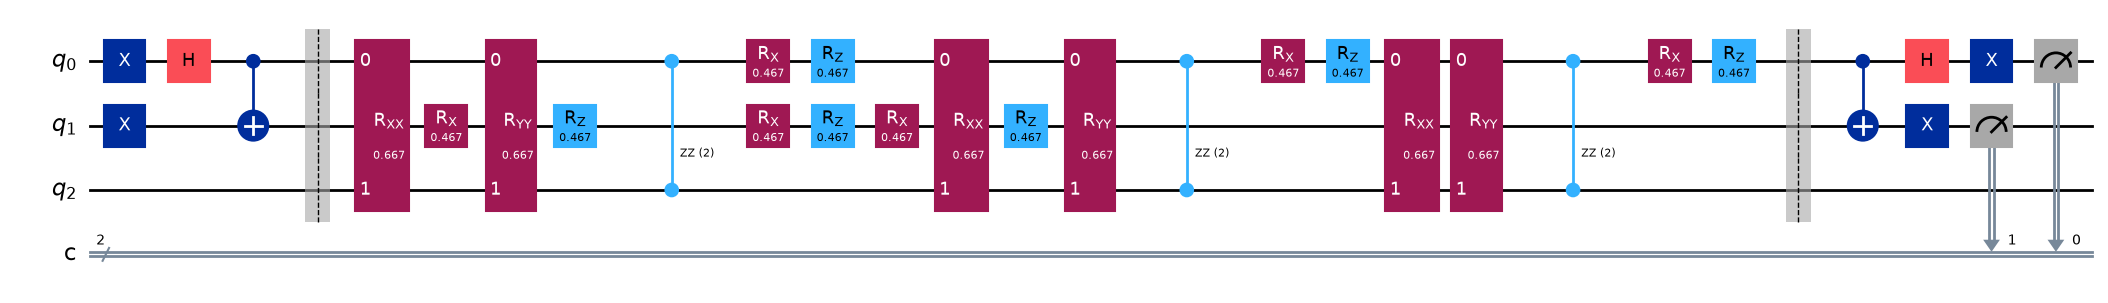

*The three-qubit circuit for one field setting: singlet preparation on qubits 0 and 1, the Trotter evolution, then inverse preparation so that reading `00` measures singlet survival. Drawn with 3 Trotter steps for legibility; the runs use 50.*

In [3]:
from qiskit import ClassicalRegister, QuantumCircuit
from qiskit.circuit import QuantumRegister
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from scipy.linalg import expm


def trotter_step(qreg, Bx, Bz, dt):
    """One first-order Trotter step of exp(-i*H*dt). R_P(theta) uses theta = 2*coeff*dt."""
    qc = QuantumCircuit(qreg)
    qc.rxx(2.0 * 1.0 * dt, qreg[0], qreg[2])
    qc.ryy(2.0 * 1.0 * dt, qreg[0], qreg[2])
    qc.rzz(2.0 * 3.0 * dt, qreg[0], qreg[2])
    qc.rx(2.0 * Bx * dt, qreg[0])
    qc.rx(2.0 * Bx * dt, qreg[1])
    qc.rz(2.0 * Bz * dt, qreg[0])
    qc.rz(2.0 * Bz * dt, qreg[1])
    return qc


def build_circuit(total_time, steps, Bx, Bz, measure=True):
    qreg = QuantumRegister(3, "q")
    qc = QuantumCircuit(qreg)
    # singlet prep on q0,q1:  |00> --X0--> |10> --X1--> |11> --H0--> (|01>-|11>)/sqrt2
    #                              --CX(0,1)--> (|01>-|10>)/sqrt2  (the singlet)
    qc.x(qreg[0])
    qc.x(qreg[1])
    qc.h(qreg[0])
    qc.cx(qreg[0], qreg[1])
    qc.barrier()
    dt = total_time / steps
    step = trotter_step(qreg, Bx, Bz, dt)
    for _ in range(steps):
        qc.compose(step, inplace=True)
    qc.barrier()
    # inverse prep: maps the singlet back to |00> so '00' measures the singlet operator
    qc.cx(qreg[0], qreg[1])
    qc.h(qreg[0])
    qc.x(qreg[0])
    qc.x(qreg[1])
    if measure:
        creg = ClassicalRegister(2, "c")
        qc.add_register(creg)
        qc.measure(0, creg[0])
        qc.measure(1, creg[1])
    return qc


demo = build_circuit(
    total_time=1.0, steps=3, Bx=0.7, Bz=0.7
)  # 3 steps so it's readable
display(demo.draw("mpl", fold=-1))
display(
    Markdown(
        "*The three-qubit circuit for one field setting: singlet preparation on qubits 0 and 1, "
        "the Trotter evolution, then inverse preparation so that reading `00` measures singlet "
        "survival. Drawn with 3 Trotter steps for legibility; the runs use 50.*"
    )
)

> **In plain English.** We chop the smooth, continuous evolution into 50 thin time slices
> and apply a few simple gates for each slice, the way many still frames add up to smooth
> motion.

## Step 3. Sweep the field angle: simulator, exact theory, and real hardware

We hold the field magnitude fixed and rotate its direction, $\theta$ from 0 to $\pi$, at
each angle running the circuit and reading the singlet survival probability. We overlay
three things on one plot for the *same* single-nucleus model:

- the **exact** result from directly exponentiating $H$,
- the **simulator** (shot noise only), and
- a **real IBM hardware** run of these exact circuits (job `d94n6clgc6cc73ffas6g`,
  `ibm_kingston`, 1024 shots per angle), pre-recorded in `data/hardware_sweep.json`.

The observable is $P(\texttt{00})$ on qubits 0 and 1 with qubit 2 free, so the exact
projector sums over both nuclear states. Concretely we measure

$$P_S(t) \;=\; \big|\langle S\,|\,\psi(t)\rangle\big|^2,
\qquad B_x = B\sin\theta,\;\; B_z = B\cos\theta,$$

where $\theta$ is the field direction we sweep.

In [4]:
def exact_singlet_survival(total_time, Bx, Bz):
    """Exact P(singlet on q0,q1) after continuous evolution, nucleus (q2) traced free."""
    H = SparsePauliOp.from_list(
        [
            ("XIX", 1.0),
            ("YIY", 1.0),
            ("ZIZ", 3.0),  # little-endian: leftmost = q0
            ("IIX", Bx),
            ("IXI", Bx),
            ("IIZ", Bz),
            ("IZI", Bz),
        ]
    )
    U = expm(-1j * total_time * H.to_matrix())

    def idx(q0, q1, q2):
        return q2 * 4 + q1 * 2 + q0

    psi0 = np.zeros(8, dtype=complex)
    psi0[idx(0, 1, 0)] = 1 / np.sqrt(2)
    psi0[idx(1, 0, 0)] = -1 / np.sqrt(2)
    psit = U @ psi0
    ps = 0.0
    for q2 in (0, 1):
        s = np.zeros(8, dtype=complex)
        s[idx(0, 1, q2)] = 1 / np.sqrt(2)
        s[idx(1, 0, q2)] = -1 / np.sqrt(2)
        ps += abs(np.vdot(s, psit)) ** 2
    return ps


B_TOT, TOTAL_TIME, STEPS, SHOTS = 1.0, 1.0, 50, 4096
thetas = np.linspace(0.0, np.pi, 10)
sim = AerSimulator()

ps_sim, ps_exact = [], []
for theta in thetas:
    Bx, Bz = B_TOT * np.sin(theta), B_TOT * np.cos(theta)
    qc = build_circuit(TOTAL_TIME, STEPS, Bx, Bz)
    counts = (
        sim.run(qc, shots=SHOTS, seed_simulator=42).result().get_counts()
    )  # seeded => reproducible
    ps_sim.append(counts.get("00", 0) / SHOTS)
    ps_exact.append(exact_singlet_survival(TOTAL_TIME, Bx, Bz))

ps_sim, ps_exact = np.array(ps_sim), np.array(ps_exact)

# pre-recorded real-hardware run of the SAME circuits (same thetas, |B|, time, steps)
hw = json.load(open(DATA / "hardware_sweep.json"))
ps_hw = np.array(hw["ps_hw"])

mae_sim = np.mean(np.abs(ps_sim - ps_exact))
mae_hw = np.mean(np.abs(ps_hw - ps_exact))
max_hw = np.max(np.abs(ps_hw - ps_exact))
display(
    Markdown(
        f"**Simulator vs exact theory:** mean absolute error {mae_sim:.4f}  \n"
        f"**Hardware vs exact theory:** mean absolute error {mae_hw:.4f} (worst angle {max_hw:.4f})"
    )
)

**Simulator vs exact theory:** mean absolute error 0.0056  
**Hardware vs exact theory:** mean absolute error 0.0147 (worst angle 0.0286)

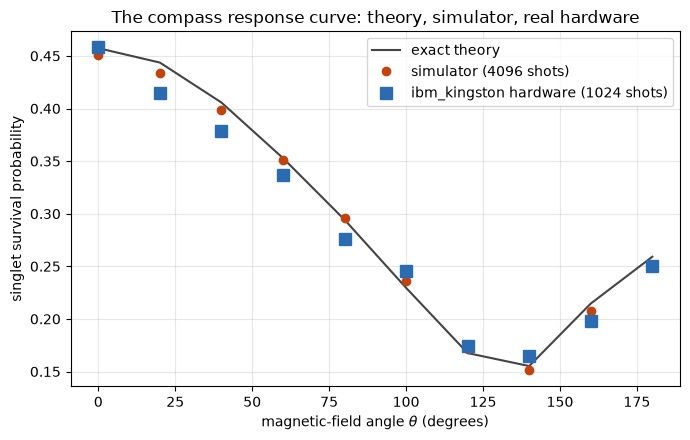

*Singlet survival versus field angle. Exact theory (line), the simulator (orange), and the real ibm_kingston run (blue) all trace the same compass response curve.*

In [5]:
plt.figure(figsize=(7, 4.5))
plt.plot(np.degrees(thetas), ps_exact, "-", color="#444", label="exact theory")
plt.plot(
    np.degrees(thetas), ps_sim, "o", color="#c1440e", label=f"simulator ({SHOTS} shots)"
)
plt.plot(
    np.degrees(thetas),
    ps_hw,
    "s",
    color="#2b6cb0",
    markersize=8,
    label="ibm_kingston hardware (1024 shots)",
)
plt.xlabel(r"magnetic-field angle $\theta$ (degrees)")
plt.ylabel("singlet survival probability")
plt.title("The compass response curve: theory, simulator, real hardware")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(
    Markdown(
        "*Singlet survival versus field angle. Exact theory (line), the simulator (orange), and "
        "the real ibm_kingston run (blue) all trace the same compass response curve.*"
    )
)

All three agree. The simulator tracks exact theory to within shot noise, and the real
`ibm_kingston` run follows the same curve to a mean absolute error of about 0.015 (worst
angle about 0.03). The singlet survival changes by roughly a factor of three across field
angles: that swing is the compass signal a bird's receptor would read out.

> **In plain English.** Rotating the field and watching how much of the original "in step"
> state survives traces the compass's response curve, and theory, simulator, and real hardware
> all agree.

## Step 4. A step up: a more realistic flavin model on hardware

The sweep above is the honest three-qubit toy: one nucleus, treated as spin-1/2. Below is a
**separate, more demanding experiment** on the same `ibm_kingston` processor. It is not the
same circuit as Step 3. It models the flavin radical with its real spin-1 nitrogen (N5)
hyperfine tensor, runs at 8192 shots with error mitigation (dynamical decoupling plus gate
and measurement twirling), and measures the **directional contrast** of the singlet yield,
the difference between field along and across the molecule.

We run it twice: once at today's field strength, and once at the much weaker field of the
Laschamp geomagnetic excursion. A working compass should show contrast today and lose it in
the weak field. The result below is pre-recorded in `data/compass_ladder_result_v2.json`
(job `d94t21cql68s73c9uod0`).

|  | Step 3 sweep | Step 4 flavin ladder |
| :-- | :-- | :-- |
| nucleus | one, spin-1/2 (toy) | real spin-1 nitrogen |
| we vary | field **angle** | field **strength** |
| shots | 1024 | 8192 |
| error mitigation | none | dynamical decoupling + twirling |
| what it shows | the compass response curve | the compass switching on and off |

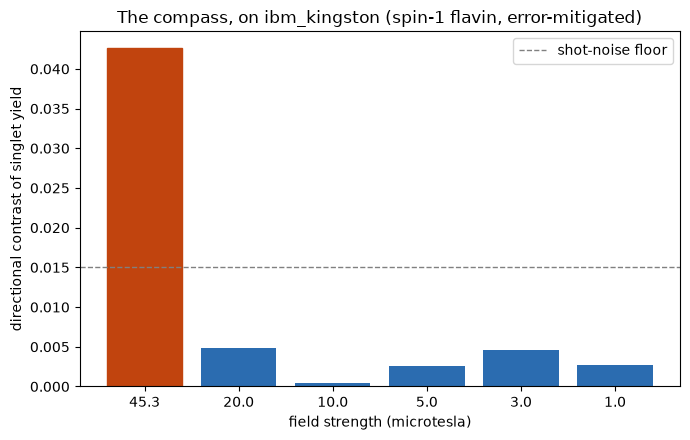

*Directional contrast of the singlet yield on real hardware. It is clearly present at today's field (orange) and collapses into the shot-noise floor at the weak Laschamp field.*

**Present-day field (45.3 uT):** contrast = 0.0426 (compass ON)  
**Laschamp weak field:** contrast = 0.0027 (compass OFF)  
**Present vs weak contrast ratio:** 0.0399

In [6]:
ladder = json.load(open(DATA / "compass_ladder_result_v2.json"))

# JSON keys are field strengths as strings ("45.3", "20.0", ...); sort high to low
keys = sorted(ladder["ladder"], key=float, reverse=True)
fields = [float(k) for k in keys]
aniso = [ladder["ladder"][k]["anisotropy"] for k in keys]

plt.figure(figsize=(7, 4.5))
bars = plt.bar([str(f) for f in fields], aniso, color="#2b6cb0")
bars[0].set_color("#c1440e")  # present-day Earth field
plt.axhline(0.015, ls="--", color="gray", lw=1, label="shot-noise floor")
plt.xlabel("field strength (microtesla)")
plt.ylabel("directional contrast of singlet yield")
plt.title("The compass, on ibm_kingston (spin-1 flavin, error-mitigated)")
plt.legend()
plt.tight_layout()
plt.show()
display(
    Markdown(
        "*Directional contrast of the singlet yield on real hardware. It is clearly present at "
        "today's field (orange) and collapses into the shot-noise floor at the weak Laschamp field.*"
    )
)

display(
    Markdown(
        f"**Present-day field ({fields[0]} uT):** contrast = {ladder['present']:.4f} (compass ON)  \n"
        f"**Laschamp weak field:** contrast = {ladder['laschamp']:.4f} (compass OFF)  \n"
        f"**Contrast drop (present - weak):** {ladder['present'] - ladder['laschamp']:.4f}  \n"
        f"**Contrast ratio (present / weak):** {ladder['present'] / ladder['laschamp']:.1f}x"
    )
)

On real hardware the directional signal is clearly present at Earth's field strength and
collapses into the noise floor at the weak Laschamp field. The compass turns on and off
roughly where the physics says it should.

> **In plain English.** A more realistic stand-in for the molecule passes the real compass
> test, working at today's field and switching off when the field gets too weak.

To reproduce a hardware run yourself, set up an IBM Quantum account once and flip the flag
below. It is off by default so this notebook runs anywhere without hitting a queue.

In [7]:
RUN_ON_HARDWARE = (
    False  # set True with a saved IBM Quantum account to submit the Step-3 sweep live
)

if RUN_ON_HARDWARE:
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

    # One-time account setup (run once, then it is cached in ~/.qiskit):
    #   QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="YOUR_IBM_TOKEN")
    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
    print("backend:", backend.name)

    circuits = [
        build_circuit(TOTAL_TIME, STEPS, B_TOT * np.sin(t), B_TOT * np.cos(t))
        for t in thetas
    ]
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    job = SamplerV2(mode=backend).run(pm.run(circuits), shots=SHOTS)
    print("job id:", job.job_id())

    # Retrieve results later (or in a fresh session) with the job id:
    #   result = QiskitRuntimeService().job("JOB_ID").result()
    #   counts = result[0].data.c.get_counts()   # 'c' is the classical register name
    #   p00 = counts.get("00", 0) / sum(counts.values())

## Step 5. GPT interprets the results

We give GPT the simulator sweep next to the exact curve, plus the real-hardware error,
and ask it to separate physical signal from noise and say what the shape means for the
compass.

In [8]:
table = "theta_deg, P_singlet_sim, P_singlet_exact\n" + "\n".join(
    f"{d:.0f}, {s:.3f}, {e:.3f}"
    for d, s, e in zip(np.degrees(thetas), ps_sim, ps_exact, strict=False)
)
INTERP_SYSTEM = (
    "You are interpreting quantum-simulation output for a reader who codes but is not a "
    "physicist. Separate physical signal from noise. Be specific, not reassuring. "
    "Do not invent citations or attribute specific behavioral results to specific animal "
    "species; discuss the mechanism generally. Keep the answer under about 600 words. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "any math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells "
    "use plain text or backticks, never LaTeX. If you use a table, keep every cell to a "
    "few words and put any longer explanation in prose beneath it, never full sentences "
    "inside cells."
)
INTERP_PROMPT = f"""Here is a sweep of singlet-survival probability P_S versus magnetic-field
angle theta (0 to 180 degrees), from a Trotterized quantum circuit ({SHOTS} shots per point),
alongside the exact theoretical curve:
{table}
The circuit uses {STEPS} Trotter steps, so the Trotter discretization error is on the order
of 1e-4 and negligible here; residuals at this shot count are dominated by shot noise.
(1) What does the shape of P_S(theta) tell us about the chemical compass, and where is it
    most directionally sensitive?
(2) Which features are physical signal versus shot noise?
(3) The simulator tracks theory to a mean absolute error of about {mae_sim:.3f}. On real IBM
    hardware the same circuits matched theory to a mean absolute error of about {mae_hw:.3f}
    (worst angle about {max_hw:.3f}). What does that gap tell us about today's quantum
    hardware?"""

display(Markdown(ask_model(INTERP_SYSTEM, INTERP_PROMPT)))

### 1) What the shape says about the chemical compass

The curve is **not flat**, so the singlet yield depends on field angle. That is the core “compass” signal: the reaction outcome is orientation-dependent.

The shape is also **smooth and anisotropic**, with a broad maximum near $0^\circ$ and a broad minimum around $120^\circ$ to $140^\circ$. That means the system is sensitive to the **direction of the field relative to the molecular frame**, not just its strength.

**Most directional sensitivity** is where the slope is steepest, roughly:
- **$60^\circ$ to $120^\circ$** on the descending side
- especially around **$80^\circ$ to $120^\circ$**

Near the top around $0^\circ$ to $40^\circ$ and near the bottom around $120^\circ$ to $160^\circ$, the curve is flatter, so small angle changes produce smaller changes in $P_S$.

### 2) Physical signal vs shot noise

**Physical signal**
- The overall **monotonic decrease** from about $0^\circ$ to $\sim 130^\circ$
- The **broad minimum** around $120^\circ$ to $140^\circ$
- The **slight recovery** toward $180^\circ$
- The fact that the simulated points follow the exact curve’s **same shape**

These are too coherent to be noise. They reflect the underlying spin dynamics.

**Shot noise**
- The pointwise deviations of size a few thousandths to maybe around $0.01$
- Example: at $0^\circ$, sim $0.451$ vs exact $0.457$
- At $140^\circ$, sim $0.151$ vs exact $0.155$
- At $180^\circ$, sim $0.251$ vs exact $0.259$

With 4096 shots, statistical uncertainty per point is roughly $\sqrt{p(1-p)/N}$, which is typically around $0.007$ to $0.008$ for probabilities in this range. So residuals of this size are exactly what you would expect from sampling noise.

### 3) What the simulator-vs-hardware gap says

A mean absolute error of about **0.006** for the simulator and **0.015** on IBM hardware means:

- The simulator is close enough that the remaining mismatch is mostly **finite-shot sampling**, not algorithmic failure.
- Hardware adds an extra error budget of about **$0.009$ absolute** on average beyond the simulator level.
- That extra gap is likely from **gate errors, decoherence, readout error, calibration drift, and crosstalk**, not from the Trotterization itself.

The key takeaway is that today’s hardware can still preserve the **qualitative compass signal** and even track it reasonably well, but it is **not yet precise enough to make the hardware noise negligible** at this circuit depth. In practice:

- The signal survives
- The curve shape is still recoverable
- But angle-by-angle quantitative agreement is degraded enough that error mitigation or shorter circuits would matter if you need tighter accuracy

So the hardware is already in the regime of **useful but noisy analog-to-digital approximation**: it can reproduce the trend, but it is not yet matching ideal simulation at the shot-noise floor.

> **In plain English.** We hand the numbers back to GPT as a skeptical lab partner to
> sort real signal from measurement noise.

## Step 6. The honest question: do we even need a quantum computer?

Quantum-biology demos usually stop here, at "look, it ran on a QPU." The more useful
question is whether a quantum computer is the *right tool* for this observable. The answer
turns out to be no, and understanding why is more valuable than the demo.

The catch with classical simulation is the nuclear-spin bath. A real cryptochrome has on
the order of 20 coupled nuclei. Brute-force **exact** simulation stores the full state
vector, whose size doubles with every nucleus, so it runs out of laptop memory around 10 to
11 nuclei. That looks like a wall a quantum computer should break.

But the observable we care about, the singlet yield, does not need the full state vector. A
**correlated-sampling typicality** estimator gets the same answer from a handful of random
states. We check it two ways below, both from real runs with a **fixed** sample count so the
comparison is clean:

- where exact simulation is still affordable ($N \le 10$), the estimator matches it, and
- its sample-to-sample spread keeps *shrinking* as the bath grows (a concentration-of-measure
  effect), so it stays reliable well past the point where exact simulation dies.

The two competing scalings are

$$\dim(\text{full state}) \;=\; 4\cdot 2^{N} \quad\text{(blows up)},
\qquad \text{typicality spread} \;\sim\; \frac{1}{\sqrt{\dim}} \quad\text{(shrinks)}.$$

| nuclei N | full state size | exact solve | typicality vs exact | estimator spread |
| :-- | :-- | :-- | :-- | :-- |
| 3 | 32 | 0.02 s | 0.023 | 0.024 |
| 10 | 4,096 | 7 s | 0.003 | 0.002 |
| 16 | 262,144 | out of memory | no exact to compare | 0.0003 |

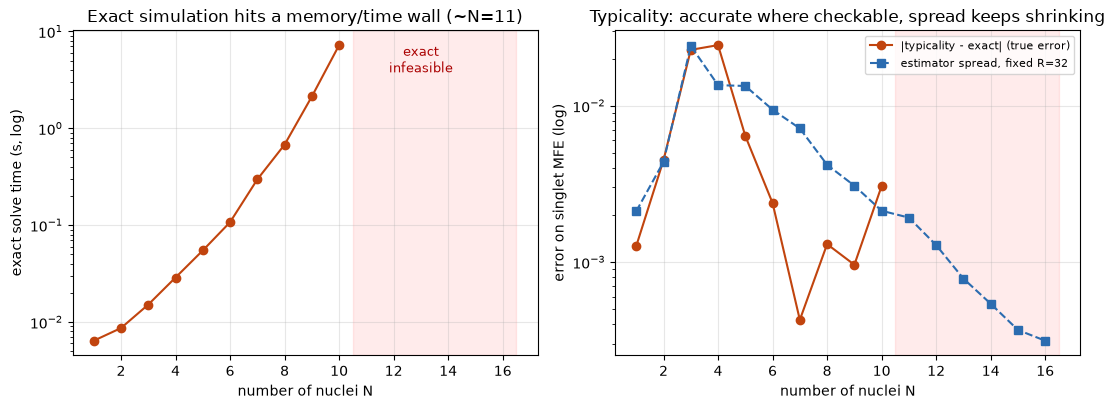

*Left: exact simulation cost explodes and runs out of laptop memory near N = 11. Right: the typicality estimator stays accurate where it can be checked, and its sample spread keeps shrinking as the nuclear bath grows.*

**Exact solve** becomes infeasible on a laptop beyond N~10 (state vector too large).  
**Typicality vs exact** where both exist (N<=10): worst error 0.0244.  
**Estimator spread** at fixed R=32: N=3 -> 0.0241, N=16 -> 0.0003 (shrinking).

In [9]:
fb = json.load(open(DATA / "frontier_benchmark.json"))
R = fb[0]["R"]

N = np.array([r["N"] for r in fb])
# left panel: exact solve time explodes and stops at the memory wall
Ne = [r["N"] for r in fb if r["exact_t"] is not None]
Te = [r["exact_t"] for r in fb if r["exact_t"] is not None]
# right panel: true accuracy where checkable, plus the estimator's own spread everywhere
Nacc = [r["N"] for r in fb if r["typ_vs_exact"] is not None]
acc = [r["typ_vs_exact"] for r in fb if r["typ_vs_exact"] is not None]
spread = [r["typ_err"] for r in fb]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.semilogy(Ne, Te, "o-", color="#c1440e")
a1.axvspan(10.5, N.max() + 0.5, color="red", alpha=0.08)
a1.text(
    13, max(Te), "exact\ninfeasible", color="#a00", ha="center", va="top", fontsize=9
)
a1.set_xlabel("number of nuclei N")
a1.set_ylabel("exact solve time (s, log)")
a1.set_title("Exact simulation hits a memory/time wall (~N=11)")
a1.grid(alpha=0.3)

a2.semilogy(Nacc, acc, "o-", color="#c1440e", label="|typicality - exact| (true error)")
a2.semilogy(N, spread, "s--", color="#2b6cb0", label=f"estimator spread, fixed R={R}")
a2.axvspan(10.5, N.max() + 0.5, color="red", alpha=0.08)
a2.set_xlabel("number of nuclei N")
a2.set_ylabel("error on singlet MFE (log)")
a2.set_title("Typicality: accurate where checkable, spread keeps shrinking")
a2.legend(fontsize=8)
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(
    Markdown(
        "*Left: exact simulation cost explodes and runs out of laptop memory near N = 11. Right: "
        "the typicality estimator stays accurate where it can be checked, and its sample spread "
        "keeps shrinking as the nuclear bath grows.*"
    )
)

worst_acc = max(acc)
display(
    Markdown(
        f"**Exact solve** becomes infeasible on a laptop beyond N~{Ne[-1]} (state vector too large).  \n"
        f"**Typicality vs exact** where both exist (N<={Nacc[-1]}): worst error {worst_acc:.4f}.  \n"
        f"**Estimator spread** at fixed R={R}: N=3 -> {spread[2]:.4f}, N={N[-1]} -> {spread[-1]:.4f} (shrinking)."
    )
)

In [10]:
INTERP2_SYSTEM = (
    "You are a skeptical computational physicist. Do not flatter quantum computing. "
    "If a classical method wins, say so plainly and explain why. Keep the answer under "
    "about 600 words so no section is cut off. "
    "Format as Markdown that nests inside a notebook section: use bold labels or at most "
    "level-3 (###) headings, never level-1 (#) or level-2 (##), and no em-dashes. Write "
    "any math as LaTeX ($...$ inline, $$...$$ display), but inside Markdown table cells "
    "use plain text or backticks, never LaTeX. If you use a table, keep every cell to a "
    "few words and put any longer explanation in prose beneath it, never full sentences "
    "inside cells."
)
ADVANTAGE_PROMPT = f"""A popular claim is that quantum computers are needed to simulate quantum
biology such as the radical-pair compass. Evaluate this critically for THIS observable, the
magnetic-field effect on singlet yield. Facts to use (all from the runs above):
- Exact simulation of the full nuclear-spin bath stores the full state vector, costs about
  O(4 * 2^N), and becomes infeasible on a laptop around N = 10 to 11 nuclei (a memory wall).
- A correlated-sampling typicality estimator uses a FIXED number of random states (R={R}).
  Where exact simulation is still affordable (N <= {Nacc[-1]}), the estimator matches it to
  within {worst_acc:.3f} on the singlet MFE. At the SAME sample count its sample-to-sample
  spread shrinks as the bath grows (concentration of measure), from {spread[2]:.4f} at N=3 to
  {spread[-1]:.4f} at N={N[-1]}. The full ~20-nucleus bath fits in a few GB and runs on a
  laptop. There is no classical accuracy wall for this observable.
Questions:
(1) For this observable, is there any bath-size regime where a fault-tolerant quantum computer
    would actually beat classical simulation, or is the "quantum computer needed" framing wrong
    here?
(2) What related problem WOULD genuinely require quantum hardware?
Give an honest, specific verdict. It is fine to conclude quantum hardware is not needed for the
headline observable."""

display(
    Markdown(
        ask_model(INTERP2_SYSTEM, ADVANTAGE_PROMPT, model=DEEP_MODEL, max_tokens=2500)
    )
)

### Honest verdict

**For the magnetic-field effect on singlet yield, the “quantum computer needed” framing is wrong.**

The exact full-state-vector calculation hits a laptop memory wall around $N=10$ to $11$ nuclei because it stores the full Hilbert-space state, with cost roughly

$$
O(4 \cdot 2^N).
$$

But that is not the right classical baseline for this observable. The observable is a single scalar quantity: the magnetic-field effect on the singlet yield. For that, the correlated-sampling typicality estimator is the relevant method.

Using the facts given:

- With fixed sample count $R=32$, it agrees with exact simulation to within $0.024$ where exact simulation is still possible, $N \le 10$.
- At the same $R$, its sample-to-sample spread decreases with bath size, from $0.0241$ at $N=3$ to $0.0003$ at $N=16$.
- The full roughly 20-nucleus bath fits in a few GB and runs on a laptop.
- Therefore there is no observed classical accuracy wall for this observable.

That last point is the key. The bath becoming larger does not make this estimator noisier. It makes it better behaved, because of concentration of measure. So the usual slogan “Hilbert space is exponentially large, therefore we need a quantum computer” is misleading here. The exact method fails, but a more appropriate classical estimator does not.

A fault-tolerant quantum computer would also have to estimate a scalar expectation value or yield difference to finite precision. That means repeated measurements, state preparation, Hamiltonian simulation, error correction overhead, and readout statistics. For this particular observable and bath size, those costs are not competitive with a laptop calculation that already gives the answer.

**So for the biologically relevant radical-pair singlet-yield MFE, there is no credible bath-size regime in the stated data where fault-tolerant quantum hardware actually wins.** One could invent much larger spin baths where brute-force classical state vectors are impossible, but that is not the regime described here, and it is not evidence that quantum hardware is needed for the headline compass observable.

### What would genuinely need quantum hardware?

A related hard problem would be different in kind: not estimating a self-averaging scalar yield, but reproducing or sampling the full many-body quantum dynamics.

Examples include:

- The full output distribution of a large interacting spin bath after coherent evolution.
- High-order, non-self-averaging spin correlation functions.
- Entanglement-resolved observables of the radical pair plus environment.
- Real-time dynamics of a chemically realistic, strongly correlated electronic-nuclear system where no compact classical representation is known.
- Phase-estimation-style calculation of many-body eigenvalues or spectral functions for a large molecular Hamiltonian.

Those are closer to problems where a fault-tolerant quantum computer is plausibly useful: the quantum device stores the wavefunction natively and can implement the Hamiltonian without explicitly storing $2^N$ amplitudes.

But that is not what the singlet-yield magnetic-field effect calculation requires. For this observable, the classical typicality method wins plainly.

> **In plain English.** Writing down the whole quantum state blows up fast, but we only
> need one number, and a sampling trick pins it down on a laptop, so here the quantum
> computer is the wrong tool and GPT says so plainly.

## Caveats and takeaways

**What this is.** A three-qubit toy (one nucleus) for the mechanism, checked against exact
theory and a real hardware run of the same circuits, plus a more realistic error-mitigated
flavin model (spin-1 nitrogen) on real hardware. Both are far from a full cryptochrome.

**What we swept under the rug.** First-order Trotter error (small here at 50 steps), shot
noise, and NISQ decoherence on the hardware runs. The toy model has a single nucleus; the
real compass has many. The two hardware experiments (Step 3 and Step 4) are different
circuits and different Hamiltonians, shown together to move from mechanism to realism, not
because one is a refinement of the other.

**The honest headline.** Running quantum biology on a quantum computer is a genuinely fun
demo, and the hardware really does reproduce the compass. But for the biologically relevant
observable, the singlet yield, a laptop with the right classical estimator wins. The place a
quantum computer would earn its keep is real-time many-body spin dynamics with many strongly
coupled nuclei and no good classical estimator, which is a fault-tolerant-era problem, not a
NISQ one.

The most useful thing GPT did in this notebook was not writing the circuit. It was telling
us, with the numbers in hand, when the quantum computer is the wrong tool.